# test_reactor_01 — Reactor batch catalítico: síntesis de NH₃

**Tipo:** Tutorial  
**Objetivo:** Primera integración temporal completa del reactor con `run_step()`. Verifica que el modelo 0D (N=1) batch con catalizador y reacción heterogénea produce resultados físicamente consistentes y que `check_balances` cierra dentro del umbral.

**Caso físico:**  
Síntesis de amoniaco N₂ + 3 H₂ → 2 NH₃ sobre catalizador de hierro en reactor batch adiabático a 10 bar inicial. La reacción exotérmica sube la temperatura del catalizador; la presión cae al reducirse el número de moles (Δn = −2 mol por mol de N₂).

**Lo que se verifica:**
- `run_step()` termina sin error
- Temperatura del catalizador sube (reacción exotérmica)
- NH₃ se forma; N₂ y H₂ se consumen
- Presión cae (Δn < 0, volumen constante)
- `check_balances` produce residuales esperados (★ energía ≈ 0, masa = fuente rxn)
- `reactor_plots` genera las figuras correctamente

**Nota sobre CSTR continuo con Δn ≠ 0:**  
El modelo continuo con la ecuación de continuidad molar `v_out = v_in · Ctot_in / Ctot_out` hace que el flujo advectivo neto siempre se cancele, por lo que `dCtot/dt = Σ source_gas`. Para reacciones con Δn < 0 esto produce caída de presión indefinida sin regulación. Un test futuro implementará el caso continuo con regulación de presión.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Raíz del proyecto (el notebook está en test/reactor/)
ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

GAS_DB = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")

from src.solvers.runner_reactor import run_step
from src.units.reactor.config.gas_props    import build_gas_prop_config
from src.units.reactor.config.boundary_c   import build_boundary_c_config
from src.units.reactor.config.thermal_bc   import build_thermal_bc_config
from src.units.reactor.config.transport    import build_transport_config
from src.units.reactor.config.initial_c    import build_initial_conditions
from src.postprocessing.reactor_balances   import check_balances
from src.postprocessing.reactor_plots      import (
    plot_temperatures, plot_gas_composition,
    plot_pressure, plot_velocities, plot_conversion, plot_summary,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print(f'ROOT: {ROOT}')
print(f'GAS_DB exists: {os.path.exists(GAS_DB)}')

ROOT: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-reactor
GAS_DB exists: True


## Parámetros físicos y geométricos

In [2]:
# ── Especies ──────────────────────────────────────────────────────────────────
SPECIES = ["N2", "H2", "NH3"]
NC      = len(SPECIES)

# ── Geometría del reactor ─────────────────────────────────────────────────────
L   = 0.5         # [m]   longitud del lecho
DI  = 0.05        # [m]   diámetro interno del tubo
DO  = 0.056       # [m]   diámetro externo (pared de 3 mm) — solo para thermal_bc
N   = 1           # [-]   número de celdas (N=1 → CSTR)
DZ  = L / N       # [m]   tamaño de celda

AI  = np.pi * (DI / 2)**2   # [m²]  sección transversal interna
PI_ = np.pi * DI             # [m]   perímetro interno
PO_ = np.pi * DO             # [m]   perímetro externo

# ── Lecho catalítico ──────────────────────────────────────────────────────────
EPSI     = 0.40    # [-]   fracción de vacíos del lecho
DP       = 0.003   # [m]   diámetro de partícula de catalizador (3 mm)
RHO_BULK = 1200.0  # [kg/m³_bed]  densidad bulk del catalizador de hierro

# Cp del catalizador (hierro con promotores, aproximación constante)
def Cp_cat(T):
    return np.ones_like(np.asarray(T, dtype=float)) * 600.0  # [J/kg/K]

# ── Condiciones de operación ──────────────────────────────────────────────────
P_OP    = 10.0    # [bar]  presión de operación
T_IN    = 700.0   # [K]    temperatura de entrada del gas
T_INIT  = 700.0   # [K]    temperatura inicial del gas y catalizador
V_IN    = 0.05    # [m/s]  velocidad superficial de entrada

# Composición de entrada: estequiométrica N₂/H₂ = 1:3
Y_IN         = np.zeros(NC)
Y_IN[SPECIES.index("N2")] = 0.25   # 25 % N₂
Y_IN[SPECIES.index("H2")] = 0.75   # 75 % H₂

# Composición inicial: misma que la de entrada (sin NH₃ al inicio)
Y_INIT       = Y_IN.copy()

GAS_T_REF    = 298.15   # [K]  temperatura de referencia para entalpías

print(f'Ai = {AI:.4e} m²   Pi = {PI_:.4f} m')
print(f'a_p = {6*(1-EPSI)/DP:.1f} m²/m³_bed  (partícula esférica dp={DP*1000:.0f} mm)')

Ai = 1.9635e-03 m²   Pi = 0.1571 m
a_p = 1200.0 m²/m³_bed  (partícula esférica dp=3 mm)


## Propiedades del gas y configuraciones

In [3]:
# ── Propiedades del gas (polinomios de gasdb) ─────────────────────────────────
prop_gas = build_gas_prop_config(
    species=SPECIES,
    mode="polynomial",
    db_path=GAS_DB,
)
MW = prop_gas["MW"]   # (nc,) [kg/mol]
print("MW [g/mol]:", {sp: f'{MW[i]*1000:.3f}' for i, sp in enumerate(SPECIES)})

# ── Condiciones de contorno: batch (v_in=None → sin flujo) ───────────────────
bc_config = build_boundary_c_config(
    n_comp=NC,
    P_out_bar=P_OP,
    v_in=None,   # batch: sistema cerrado, sin flujo de entrada ni salida
)

# ── Contorno térmico: adiabático (sin pérdidas laterales) ────────────────────
thermal_bc = build_thermal_bc_config(
    mode="adiabatic",
    Di=DI, Do=DO,
    e_wall=0.8,
)

# ── Coeficientes de transporte: modo constante ────────────────────────────────
trans_config = build_transport_config(
    mode="constant",
    N=N, n_comp=NC,
    h_bed=100.0,    # [W/m²/K]  gas↔catalizador
    h_wall=10.0,    # [W/m²/K]  gas↔pared (inactivo en modo adiabático)
)

print('Configuraciones construidas correctamente. Modo: batch (sistema cerrado).')

MW [g/mol]: {'N2': '28.014', 'H2': '2.016', 'NH3': '17.031'}
Configuraciones construidas correctamente. Modo: batch (sistema cerrado).


## Cinética de reacción

Ley de potencia para la síntesis de NH₃ sobre catalizador de hierro:

$$r = A \, e^{-E_a/(RT_s)} \, C_{N_2} \, C_{H_2}^{0.5} \quad [\text{mol/m}^3_{\text{bed}}\text{/s}]$$

Reacción heterogénea: el calor de reacción se deposita en el catalizador.

In [4]:
R_GAS = 8.31446   # [J/mol/K]

A_RXN = 2000.0    # factor preexponencial [m^1.5 mol^-0.5 s^-1]
EA    = 80000.0   # energía de activación [J/mol]
DH    = -92000.0  # calor de reacción (exotérmica) [J/mol_N2]

IDX_N2  = SPECIES.index("N2")
IDX_H2  = SPECIES.index("H2")

def rate_nh3_synthesis(C, Tg, Ts, P_Pa, params):
    """r = A*exp(-Ea/R/Ts) * C_N2 * C_H2^0.5  [mol/m³_bed/s]"""
    T = Ts if Ts is not None else Tg   # usa Ts (catalizador) si está disponible
    k = A_RXN * np.exp(-EA / (R_GAS * np.maximum(T, 300.0)))
    C_N2 = np.maximum(C[IDX_N2], 0.0)
    C_H2 = np.maximum(C[IDX_H2], 0.0)
    return k * C_N2 * np.sqrt(C_H2)   # (N,) [mol/m³_bed/s]

reactions_config = [
    {
        "type":     "heterogeneous",          # calor → catalizador (Ts)
        "stoich":   {"N2": -1, "H2": -3, "NH3": +2},
        "rate_fn":  rate_nh3_synthesis,
        "dH_rxn":   DH,                        # [J/mol_N2] negativo = exotérmica
    }
]

# Verificación: tasa a T=700 K con composición inicial
C_test    = Y_IN * P_OP*1e5 / (R_GAS * T_IN)
C_test_2d = C_test.reshape(-1, 1)   # (nc, 1) para llamar a rate_fn
Tg_test   = np.array([T_IN])
r_test    = rate_nh3_synthesis(C_test_2d, Tg_test, Tg_test, None, {})
print(f"r a T={T_IN:.0f}K, P={P_OP:.0f}bar, y_N2=0.25, y_H2=0.75:  {float(r_test):.3f} mol/m³_bed/s")
print(f"Conversión estimada SS: ~{float(r_test) * (L/V_IN) / float(C_test[IDX_N2]) * 100:.1f}%")

r a T=700K, P=10bar, y_N2=0.25, y_H2=0.75:  1.046 mol/m³_bed/s
Conversión estimada SS: ~24.4%


C:\Users\MiguelCamaraSanz\AppData\Local\Temp\ipykernel_113984\3490673637.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"r a T={T_IN:.0f}K, P={P_OP:.0f}bar, y_N2=0.25, y_H2=0.75:  {float(r_test):.3f} mol/m³_bed/s")
C:\Users\MiguelCamaraSanz\AppData\Local\Temp\ipykernel_113984\3490673637.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Conversión estimada SS: ~{float(r_test) * (L/V_IN) / float(C_test[IDX_N2]) * 100:.1f}%")


## Condiciones iniciales y dict de parámetros

In [5]:
# ── Catalizador ───────────────────────────────────────────────────────────────
catalyst_config = {
    "dp":       DP,          # [m]         diámetro de partícula
    "rho_bulk": RHO_BULK,    # [kg/m³_bed] densidad bulk
    "Cp_fn":    Cp_cat,      # callable T → [J/kg/K]
    # "a_p" se calcula automáticamente por runner: 6*(1-epsi)/dp
}

# ── Condiciones iniciales ─────────────────────────────────────────────────────
ic = build_initial_conditions(
    P_bar=P_OP, Tg=T_INIT, y=Y_INIT,
    n_comp=NC, N=N,
    prop_gas=prop_gas, epsi=EPSI, gas_T_ref=GAS_T_REF,
    Ts=T_INIT,     # catalizador a la misma temperatura inicial
    Tw=None,       # sin ODE de pared
)
sv0 = ic["sv0"]

print(f"sv0 shape:  {sv0.shape}   (nc={NC}, N={N}: {NC}*{N}C + {N}Hg + {N}Ts = {sv0.size})")
print(f"C_N2(t0)  = {ic['C_init'][IDX_N2, 0]:.2f} mol/m³_gas")
print(f"C_H2(t0)  = {ic['C_init'][IDX_H2, 0]:.2f} mol/m³_gas")
print(f"Tg(t0)    = {ic['Tg_init'][0]:.1f} K")
print(f"Ts(t0)    = {ic['Ts_init'][0]:.1f} K")
print(f"P(t0)     = {ic['P_init'][0]:.2f} bar")

# ── Params dict completo ──────────────────────────────────────────────────────
params = {
    "n_comp":          NC,
    "N":               N,
    "dz":              DZ,
    "epsi":            EPSI,
    "Ai":              AI,
    "Di":              DI,
    "Pi":              PI_,
    "Po":              PO_,
    "MW":              MW,
    "species":         SPECIES,
    "prop_gas":        prop_gas,
    "gas_T_ref":       GAS_T_REF,
    "bc_config":       bc_config,
    "thermal_bc_config": thermal_bc,
    "trans_config":    trans_config,
    "catalyst_config": catalyst_config,
    "reactions_config": reactions_config,
    "energy":          True,
}
print("\nparams dict listo.")

sv0 shape:  (5,)   (nc=3, N=1: 3*1C + 1Hg + 1Ts = 5)
C_N2(t0)  = 42.95 mol/m³_gas
C_H2(t0)  = 128.86 mol/m³_gas
Tg(t0)    = 700.0 K
Ts(t0)    = 700.0 K
P(t0)     = 10.00 bar

params dict listo.


## Configuración del solver

In [6]:
T_MAX    = 300.0    # [s]  tiempo de simulación (suficiente para ver conversión significativa)
RTOL     = 1e-6     # tolerancia relativa del integrador BDF
ATOL     = 1e-8     # tolerancia absoluta
MAX_STEP = 2.0      # [s]  paso máximo
N_SEC    = 10       # puntos de salida por segundo de simulación

## Integración temporal

In [7]:
# Limpiar caché antes de simular (buena práctica al re-ejecutar el notebook)
params.pop("_cache", None)

print("Simulando reactor batch NH₃ — N=1, adiabático, P_init=10 bar...")
t_arr, y_hist, reactor = run_step(
    sv0=sv0,
    t_max=T_MAX,
    params=params,
    rtol=RTOL,
    atol=ATOL,
    max_step=MAX_STEP,
    n_sec=N_SEC,
    show_progress=False,
)

print(f"\n✓ Integración completada.")
print(f"  Puntos de tiempo: {len(t_arr)}")
print(f"  Tg final:  {reactor._Tg_results[-1, 0]:.1f} K  ({reactor._Tg_results[-1, 0]-273.15:.1f} °C)")
print(f"  Ts final:  {reactor._Ts_results[-1, 0]:.1f} K  ({reactor._Ts_results[-1, 0]-273.15:.1f} °C)")
print(f"  P final:   {reactor._P_results[-1, 0]:.2f} bar")
print(f"  P inicial: {reactor._P_results[0, 0]:.2f} bar  (P cae por Δn < 0)")
y_final = reactor._y_results[-1, :, 0]
for i, sp in enumerate(SPECIES):
    print(f"  y_{sp} final: {y_final[i]*100:.2f} %")

Simulando reactor batch NH₃ — N=1, adiabático, P_init=10 bar...

✓ Integración completada.
  Puntos de tiempo: 3001
  Tg final:  702.8 K  (429.6 °C)
  Ts final:  702.8 K  (429.6 °C)
  P final:   5.06 bar
  P inicial: 10.00 bar  (P cae por Δn < 0)
  y_N2 final: 0.44 %
  y_H2 final: 1.33 %
  y_NH3 final: 98.23 %


## Evolución temporal de variables clave

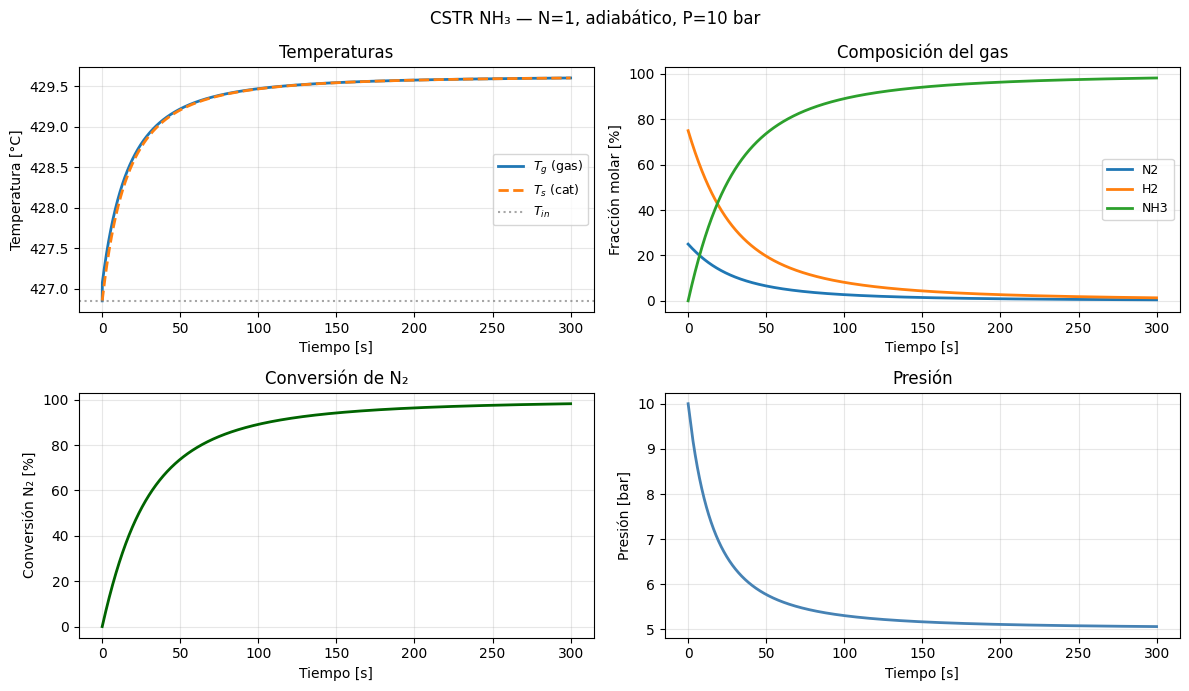

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Temperaturas
ax = axes[0, 0]
ax.plot(t_arr, reactor._Tg_results[:, 0] - 273.15, lw=2, label='$T_g$ (gas)')
ax.plot(t_arr, reactor._Ts_results[:, 0] - 273.15, lw=2, ls='--', label='$T_s$ (cat)')
ax.axhline(T_IN - 273.15, ls=':', color='gray', alpha=0.7, label='$T_{in}$')
ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('Temperatura [°C]')
ax.set_title('Temperaturas'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Composición del gas
ax = axes[0, 1]
for i, sp in enumerate(SPECIES):
    ax.plot(t_arr, reactor._y_results[:, i, 0] * 100, lw=2, label=sp)
ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('Fracción molar [%]')
ax.set_title('Composición del gas'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Conversión de N₂
ax = axes[1, 0]
y_N2_0 = float(reactor._y_results[0, IDX_N2, 0])
X_N2   = (1.0 - reactor._y_results[:, IDX_N2, 0] / y_N2_0) * 100
ax.plot(t_arr, X_N2, lw=2, color='darkgreen')
ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('Conversión N₂ [%]')
ax.set_title('Conversión de N₂'); ax.grid(True, alpha=0.3)

# Presión
ax = axes[1, 1]
ax.plot(t_arr, reactor._P_results[:, 0], lw=2, color='steelblue')
ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('Presión [bar]')
ax.set_title('Presión'); ax.grid(True, alpha=0.3)

plt.suptitle('CSTR NH₃ — N=1, adiabático, P=10 bar', fontsize=12)
plt.tight_layout()
plt.show()

## Dashboard de resultados (reactor_plots)

C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-reactor\src\postprocessing\reactor_plots.py:166: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-reactor\src\postprocessing\reactor_plots.py:211: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-reactor\src\postprocessing\reactor_plots.py:247: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-reactor\src\postprocessing\reactor_plots.py:373: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


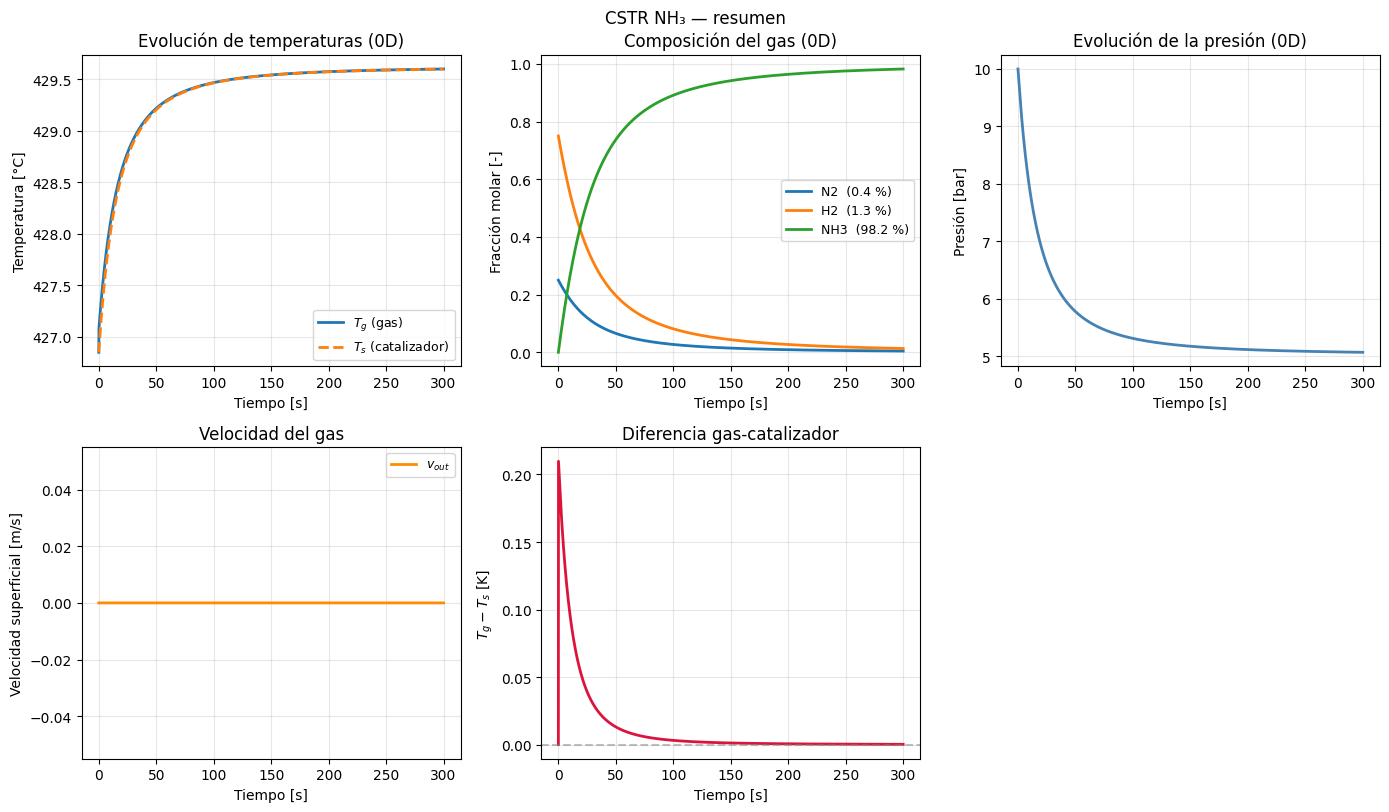

In [9]:
fig, axes = plot_summary(reactor)
fig.suptitle('CSTR NH₃ — resumen', fontsize=12, y=1.01)
plt.show()

## Verificación de balances

In [10]:
result_balances = check_balances(reactor, params, verbose=True)


════════════════════════════════════════════════════════════════════════════════
  MASA GAS  [kg/m³_bed]  (con reacciones — residual = masa reaccionada)
--------------------------------------------------------------------------------
  Variable                    Acumulacion      Flujo neto        Residual   Res [%]  Nota
--------------------------------------------------------------------------------
    m_gas total               +8.8549e-06     +0.0000e+00     +8.8549e-06  +100.00%  fuente rxn

════════════════════════════════════════════════════════════════════════════════
  ESPECIES GAS  [mol/m³_bed]  (residual = moles producidos/consumidos por rxn)
--------------------------------------------------------------------------------
  Variable                    Acumulacion      Flujo neto        Residual   Res [%]  Nota
--------------------------------------------------------------------------------
    C_N2                      -1.7029e+01     +0.0000e+00     -1.7029e+01  +100.00%  

## Interpretación de balances

```
★ = cierre numérico — residual debe ser |res/max(|Δ|,|flux|)| < 1%
    fuera del umbral → investigar max_step, tolerancias, o bug en RHS

Fuente física = se espera ≠ 0; el residual es la cantidad producida o consumida
```

**Batch — sin flujo convectivo (v_in = v_out = 0):**  
- **Masa del gas:** residual = masa consumida/producida por reacciones (fuente física ≠ 0).  
- **Especies:** residual = moles netos reaccionados (N₂ y H₂ negativos, NH₃ positivo).  
- **Energía del gas (★):** debe cerrar. En batch sin flujo, ΔHg = -Q_gs (gas cede calor al sólido).  
- **Energía del sólido (★):** ΔHs = Q_gs + Q_rxn. El calor de reacción deposita en el catalizador.

**Presión:** cae porque N₂+3H₂→2NH₃ tiene Δn=-2 por mol N₂. En volumen constante, menos moles → menor P. Comportamiento físicamente correcto para un reactor batch.

## Conclusiones

Este test demuestra que:
1. `run_step()` integra correctamente el reactor batch catalítico N=1 con reacción heterogénea.
2. La temperatura del catalizador (Ts) sube por la reacción exotérmica; el gas (Tg) la sigue vía q_gs.
3. NH₃ se forma y N₂/H₂ se consumen de acuerdo con la estequiometría.
4. La presión cae correctamente (Δn < 0 en volumen constante).
5. `check_balances` confirma cierre ★ energético < 1% y residuales físicos coherentes en masa/especies.
6. `reactor_plots` genera todas las figuras del módulo sin errores.

**Próximos tests:**
- `test_reactor_02`: perfil 1D (N=10) — ver distribución axial de temperatura y composición.
- `test_reactor_03`: CSTR continuo con regulación de presión (modelo extendido).